In [2]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np

def get_dataframe_from_records(records, add_custom_columns=None):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    if add_custom_columns:
        df = add_custom_columns(df)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def get_records(project, metrics=[], verbose=False):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    runs = api.runs(f"{entity}/{project}")

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not run.group or not run.group.startswith("best_"):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        if verbose:
            print(f"Processing run {run.id} in group '{group}'")
            # print metrics of the run
            print("Metrics:", [key for key in run.summary.keys() if key.startswith("test_")])

        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        records.append(record)
    return records

def style_mean_column(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    top2_idx = mean_vals.nlargest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles


In [3]:
ft_groups = ['best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_xlstm_sup']

lp_groups = ['best_ecgfm_lp', 'best_jepa_lp', 'best_stmem_lp', 'best_trans_lp', 'best_xlstm_lp']

# PTB-XL metrics

In [4]:
metrics = ["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime']
records_ptb_xl = get_records("train-ptbxl-diagnosis_superclass-multilabel", metrics=metrics)
formatted_df = get_dataframe_from_records(records_ptb_xl)

100%|██████████| 471/471 [01:09<00:00,  6.75it/s]


## Finetuning

In [5]:
# ands with _ft or _sup
ptbxl_ft = formatted_df[formatted_df.index.isin(ft_groups)]
styled_df = ptbxl_ft.style.apply(style_mean_column)
styled_df

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_ft,0.891 ± 0.001,0.734 ± 0.002,0.930 ± 0.000,0.822 ± 0.001,805.316 ± 8.746
best_jepa_ft,0.884 ± 0.001,0.733 ± 0.003,0.923 ± 0.000,0.809 ± 0.000,5650.440 ± 26.342
best_stmem_ft,0.892 ± 0.001,0.739 ± 0.005,0.930 ± 0.001,0.822 ± 0.002,3879.754 ± 15.904
best_trans_ft,0.880 ± 0.002,0.710 ± 0.017,0.925 ± 0.001,0.808 ± 0.001,323.377 ± 16.639
best_xlstm_ft,0.885 ± 0.001,0.720 ± 0.013,0.928 ± 0.001,0.817 ± 0.003,474.918 ± 27.461
best_xlstm_sup,0.860 ± 0.005,0.667 ± 0.007,0.891 ± 0.004,0.748 ± 0.006,499.091 ± 15.265


## Linear probing

In [6]:
agg_df_full_lp = formatted_df[formatted_df.index.str.endswith("_lp")]
styled_df_lp = agg_df_full_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp,0.883 ± 0.001,0.702 ± 0.002,0.917 ± 0.000,0.799 ± 0.000,377.904 ± 4.972
best_jepa_lp,0.864 ± 0.001,0.712 ± 0.002,0.902 ± 0.000,0.769 ± 0.000,2091.479 ± 4.906
best_stmem_lp,0.847 ± 0.001,0.564 ± 0.002,0.867 ± 0.001,0.693 ± 0.001,1493.105 ± 2.861
best_trans_lp,0.875 ± 0.001,0.703 ± 0.002,0.914 ± 0.000,0.782 ± 0.001,228.304 ± 4.401
best_xlstm_lp,0.876 ± 0.001,0.690 ± 0.001,0.915 ± 0.000,0.788 ± 0.001,322.295 ± 6.590


## Linear probing 10%

In [7]:
agg_df_10 = formatted_df[formatted_df.index.str.endswith("_10")]
styled_df_10 = agg_df_10.style.apply(style_mean_column)
styled_df_10

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_10,0.868 ± 0.001,0.616 ± 0.006,0.891 ± 0.001,0.745 ± 0.004,219.112 ± 32.960
best_jepa_lp_10,0.789 ± 0.003,0.638 ± 0.003,0.878 ± 0.002,0.711 ± 0.011,522.137 ± 8.870
best_stmem_lp_10,0.808 ± 0.001,0.314 ± 0.015,0.816 ± 0.002,0.565 ± 0.007,423.572 ± 3.300
best_trans_lp_10,0.862 ± 0.001,0.663 ± 0.004,0.893 ± 0.001,0.741 ± 0.002,162.728 ± 19.854
best_xlstm_lp_10,0.859 ± 0.002,0.613 ± 0.002,0.884 ± 0.002,0.718 ± 0.010,164.256 ± 5.382


## Linear probing 1%

In [8]:
agg_df_1 = formatted_df[formatted_df.index.str.endswith("_1")]
styled_df_1 = agg_df_1.style.apply(style_mean_column)
styled_df_1

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_1,0.849 ± 0.005,0.623 ± 0.012,0.864 ± 0.007,0.678 ± 0.019,155.753 ± 22.135
best_jepa_lp_1,0.722 ± 0.012,0.571 ± 0.010,0.825 ± 0.008,0.615 ± 0.018,292.139 ± 34.668
best_stmem_lp_1,0.799 ± 0.003,0.343 ± 0.014,0.769 ± 0.004,0.506 ± 0.009,306.723 ± 3.040
best_trans_lp_1,0.749 ± 0.015,0.595 ± 0.009,0.841 ± 0.006,0.633 ± 0.010,88.689 ± 5.228
best_xlstm_lp_1,0.827 ± 0.007,0.526 ± 0.042,0.836 ± 0.008,0.621 ± 0.009,155.339 ± 37.376


# CPSC 2018

In [9]:
records_cpsc = get_records("train-cpsc2018-multilabel", metrics=["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime'])
formatted_df_cpsc = get_dataframe_from_records(records_cpsc)

100%|██████████| 307/307 [00:44<00:00,  6.91it/s]


## Finetuning

In [10]:
cpsc_ft = formatted_df_cpsc[formatted_df_cpsc.index.isin(ft_groups)]

styled_df_ft = cpsc_ft.style.apply(style_mean_column)
styled_df_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_ft,0.964 ± 0.000,0.794 ± 0.005,0.969 ± 0.001,0.854 ± 0.002,406.169 ± 10.301
best_jepa_ft,0.942 ± 0.003,0.749 ± 0.009,0.965 ± 0.001,0.842 ± 0.003,1705.833 ± 44.027
best_stmem_ft,0.963 ± 0.001,0.789 ± 0.012,0.958 ± 0.003,0.835 ± 0.011,1314.123 ± 14.290
best_trans_ft,0.961 ± 0.001,0.796 ± 0.008,0.965 ± 0.003,0.853 ± 0.006,212.527 ± 12.297
best_xlstm_ft,0.968 ± 0.001,0.822 ± 0.008,0.981 ± 0.001,0.888 ± 0.003,731.973 ± 30.716
best_xlstm_sup,0.952 ± 0.001,0.719 ± 0.008,0.951 ± 0.002,0.813 ± 0.006,846.747 ± 71.359


## Linear probing

In [11]:
formatted_df_cpsc_lp = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_lp")]
styled_df_lp = formatted_df_cpsc_lp.style.apply(style_mean_column)
styled_df_lp


,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp,0.958 ± 0.000,0.750 ± 0.007,0.962 ± 0.000,0.830 ± 0.001,252.192 ± 4.276
best_jepa_lp,0.889 ± 0.002,0.613 ± 0.003,0.961 ± 0.000,0.830 ± 0.001,746.866 ± 3.697
best_stmem_lp,0.935 ± 0.000,0.455 ± 0.005,0.922 ± 0.001,0.722 ± 0.004,604.956 ± 2.832
best_trans_lp,0.953 ± 0.001,0.733 ± 0.008,0.951 ± 0.001,0.787 ± 0.008,248.633 ± 32.202
best_xlstm_lp,0.961 ± 0.002,0.781 ± 0.011,0.968 ± 0.001,0.861 ± 0.004,461.689 ± 6.262


## Linear probing 10%


In [12]:
formatted_df_cpsc_10 = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_10")]
styled_df_cpsc_10 = formatted_df_cpsc_10.style.apply(style_mean_column)
styled_df_cpsc_10

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_10,0.913 ± 0.002,0.182 ± 0.011,0.919 ± 0.003,0.672 ± 0.012,197.652 ± 3.593
best_jepa_lp_10,0.748 ± 0.004,0.451 ± 0.003,0.934 ± 0.007,0.763 ± 0.013,316.687 ± 3.869
best_stmem_lp_10,0.885 ± 0.003,0.027 ± 0.016,0.798 ± 0.010,0.448 ± 0.005,294.200 ± 5.431
best_trans_lp_10,0.789 ± 0.013,0.461 ± 0.011,0.898 ± 0.006,0.653 ± 0.012,151.518 ± 10.365
best_xlstm_lp_10,0.930 ± 0.002,0.406 ± 0.025,0.913 ± 0.007,0.689 ± 0.027,237.764 ± 5.794


## Linear probing 1%

In [13]:
formatted_df_cpsc_1 = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_1")]
styled_df_cpsc_1 = formatted_df_cpsc_1.style.apply(style_mean_column)
styled_df_cpsc_1

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_1,0.933 ± 0.005,0.481 ± 0.073,0.920 ± 0.007,0.678 ± 0.012,141.167 ± 17.314
best_jepa_lp_1,0.674 ± 0.007,0.384 ± 0.007,0.878 ± 0.010,0.598 ± 0.020,141.575 ± 20.931
best_stmem_lp_1,0.908 ± 0.006,0.250 ± 0.043,0.827 ± 0.012,0.479 ± 0.024,226.514 ± 3.257
best_trans_lp_1,0.714 ± 0.021,0.389 ± 0.017,0.827 ± 0.013,0.515 ± 0.011,64.556 ± 7.530
best_xlstm_lp_1,0.915 ± 0.010,0.401 ± 0.086,0.873 ± 0.015,0.591 ± 0.029,174.486 ± 7.431


# MIT-BIH classification

In [14]:
records_mit_cls = get_records("train-mitbih-5", metrics=["test_acc", "test_sensitivity/mean", "test_ppv/mean", "test_specificity/mean", "test_f1/mean", '_runtime'])
formatted_df_mit_cls = get_dataframe_from_records(records_mit_cls)

100%|██████████| 279/279 [00:39<00:00,  7.01it/s]


## Finetuning

In [15]:
mit_ft = formatted_df_mit_cls[formatted_df_mit_cls.index.isin(ft_groups)]

styled_df_mit_ft = mit_ft.style.apply(style_mean_column)
styled_df_mit_ft

,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_ecgfm_ft,0.863 ± 0.008,0.211 ± 0.002,0.207 ± 0.002,0.809 ± 0.002,0.207 ± 0.002,309.187 ± 37.117
best_jepa_ft,0.954 ± 0.001,0.555 ± 0.007,0.626 ± 0.007,0.950 ± 0.001,0.581 ± 0.007,2141.945 ± 252.625
best_stmem_ft,0.967 ± 0.002,0.624 ± 0.007,0.671 ± 0.013,0.964 ± 0.003,0.644 ± 0.007,1796.177 ± 13.793
best_trans_ft,0.896 ± 0.008,0.475 ± 0.002,0.457 ± 0.005,0.905 ± 0.001,0.425 ± 0.006,216.098 ± 25.243
best_xlstm_ft,0.976 ± 0.007,0.651 ± 0.035,0.721 ± 0.019,0.973 ± 0.010,0.677 ± 0.025,708.598 ± 34.795
best_xlstm_sup,0.896 ± 0.013,0.448 ± 0.028,0.416 ± 0.020,0.910 ± 0.004,0.402 ± 0.014,748.898 ± 4.569


## Linear probing

In [16]:
formatted_mit_lp = formatted_df_mit_cls[formatted_df_mit_cls.index.str.endswith("_lp")]
styled_df_mit_lp = formatted_mit_lp.style.apply(style_mean_column)
styled_df_mit_lp


,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_ecgfm_lp,0.869 ± 0.012,0.210 ± 0.003,0.210 ± 0.004,0.807 ± 0.003,0.206 ± 0.004,307.799 ± 34.078
best_jepa_lp,0.946 ± 0.000,0.470 ± 0.003,0.574 ± 0.003,0.933 ± 0.000,0.496 ± 0.003,891.782 ± 8.916
best_stmem_lp,0.936 ± 0.003,0.414 ± 0.012,0.503 ± 0.032,0.920 ± 0.002,0.424 ± 0.019,814.539 ± 91.461
best_trans_lp,0.931 ± 0.000,0.381 ± 0.004,0.549 ± 0.012,0.924 ± 0.004,0.395 ± 0.005,108.508 ± 2.805
best_xlstm_lp,0.972 ± 0.002,0.686 ± 0.021,0.669 ± 0.014,0.976 ± 0.003,0.674 ± 0.013,326.174 ± 3.404


# MIT-BIH r-peaks

In [17]:
records_mit_r_peaks = get_records("train-mitbih-r_peaks", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance", '_runtime'])
formatted_df_mit_r_peaks = get_dataframe_from_records(records_mit_r_peaks)

100%|██████████| 133/133 [00:14<00:00,  9.00it/s]


## Fine-tuning

In [18]:
mit_r_peaks_ft = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.isin(ft_groups)]
# add sup rows to ft
styled_df_mit_r_peaks_ft = mit_r_peaks_ft.style.apply(style_mean_column)
styled_df_mit_r_peaks_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.081 ± 0.006,0.011 ± 0.001,3794.272 ± 789.848,309.131 ± 14.947
best_jepa_ft,0.996 ± 0.000,0.909 ± 0.004,4.195 ± 0.059,1364.272 ± 16.953
best_stmem_ft,0.994 ± 0.001,0.937 ± 0.001,5.148 ± 0.403,1102.879 ± 9.398
best_trans_ft,0.983 ± 0.001,0.900 ± 0.001,7.587 ± 0.159,278.538 ± 11.780
best_xlstm_ft,0.995 ± 0.000,0.921 ± 0.001,5.208 ± 0.098,223.998 ± 15.288
best_xlstm_sup,0.980 ± 0.007,0.889 ± 0.012,8.217 ± 1.056,191.553 ± 22.564


## Linear probing

In [19]:
formatted_df_mit_r_peaks_lp = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.str.endswith("_lp")]
styled_df_mit_r_peaks_lp = formatted_df_mit_r_peaks_lp.style.apply(style_mean_column)
styled_df_mit_r_peaks_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.073 ± 0.005,0.010 ± 0.001,4564.209 ± 630.534,309.113 ± 5.623
best_jepa_lp,0.976 ± 0.000,0.444 ± 0.001,6.858 ± 0.016,602.930 ± 14.573
best_stmem_lp,0.970 ± 0.001,0.564 ± 0.002,7.430 ± 0.139,502.377 ± 19.211
best_trans_lp,0.864 ± 0.001,0.476 ± 0.000,32.177 ± 0.086,150.891 ± 4.207
best_xlstm_lp,0.945 ± 0.005,0.590 ± 0.011,11.487 ± 0.283,143.034 ± 18.259


# Exercise high intensity r peaks

In [20]:
records_exe_r = get_records("train-exercise-r_peak", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance", '_runtime'])
formatted_df_exe_r = get_dataframe_from_records(records_exe_r)

100%|██████████| 137/137 [00:15<00:00,  8.96it/s]

In [21]:
# print all groups
print("Groups in formatted_df_exe_r:")
print(formatted_df_exe_r.index.tolist())

Groups in formatted_df_exe_r:
['best_ecgfm_ft', 'best_ecgfm_lp', 'best_jepa_ft', 'best_jepa_lp', 'best_stmem_ft', 'best_stmem_lp', 'best_trans_ft', 'best_trans_lp', 'best_xlstm_ft', 'best_xlstm_lp', 'best_xlstm_sup']


# Finetuning

In [22]:
exe_r_ft = formatted_df_exe_r[formatted_df_exe_r.index.isin(ft_groups)]
# add sup rows to ft
styled_df_exe_r_ft = exe_r_ft.style.apply(style_mean_column)
styled_df_exe_r_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.426 ± 0.006,0.082 ± 0.005,53.058 ± 1.501,59.386 ± 14.401
best_jepa_ft,0.975 ± 0.002,0.857 ± 0.008,3.716 ± 0.161,219.677 ± 4.496
best_stmem_ft,0.988 ± 0.002,0.986 ± 0.001,3.284 ± 0.456,202.898 ± 5.310
best_trans_ft,0.850 ± 0.006,0.631 ± 0.011,12.475 ± 0.484,165.081 ± 17.135
best_xlstm_ft,0.996 ± 0.001,0.968 ± 0.002,3.983 ± 0.231,132.740 ± 9.662
best_xlstm_sup,0.990 ± 0.002,0.966 ± 0.002,5.832 ± 0.507,106.686 ± 7.300


# Linear probing

In [23]:
formatted_exe_r_lp = formatted_df_exe_r[formatted_df_exe_r.index.str.endswith("_lp")]
styled_df_exe_r_lp = formatted_exe_r_lp.style.apply(style_mean_column)
styled_df_exe_r_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.420 ± 0.016,0.082 ± 0.002,52.658 ± 3.061,67.271 ± 22.722
best_jepa_lp,0.924 ± 0.004,0.525 ± 0.007,13.473 ± 0.940,133.192 ± 4.527
best_stmem_lp,0.822 ± 0.018,0.627 ± 0.008,44.091 ± 10.828,135.491 ± 4.775
best_trans_lp,0.605 ± 0.006,0.302 ± 0.002,25.289 ± 0.381,87.545 ± 3.047
best_xlstm_lp,0.948 ± 0.004,0.891 ± 0.004,17.983 ± 1.049,59.657 ± 38.003


# Sleep apnea

In [24]:
records_sleep_apnea = get_records("train-sleep-apnea", metrics=["test_acc", "test_f1", "test_auc", '_runtime'])
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)

100%|██████████| 203/203 [00:26<00:00,  7.77it/s]


# Fine-tuning

In [25]:
sleep_ft = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.isin(ft_groups)]
# add sup rows to ft
styled_df_sleep_ft = sleep_ft.style.apply(style_mean_column)
styled_df_sleep_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.575 ± 0.018,0.566 ± 0.017,0.580 ± 0.021,464.375 ± 160.381
best_jepa_ft,0.612 ± 0.037,0.592 ± 0.032,0.587 ± 0.032,11777.192 ± 1995.169
best_stmem_ft,0.604 ± 0.029,0.600 ± 0.033,0.727 ± 0.035,4657.244 ± 690.356
best_trans_ft,0.563 ± 0.033,0.558 ± 0.030,0.604 ± 0.058,825.681 ± 150.267
best_xlstm_ft,0.853 ± 0.007,0.802 ± 0.011,0.869 ± 0.004,5694.219 ± 21.425
best_xlstm_sup,0.763 ± 0.036,0.685 ± 0.044,0.783 ± 0.043,5093.147 ± 958.403


# Linear probing

In [26]:
formatted_sleep_lp = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.str.endswith("_lp")]
styled_df_sleep_lp = formatted_sleep_lp.style.apply(style_mean_column)
styled_df_sleep_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.555 ± 0.060,0.548 ± 0.067,0.579 ± 0.082,328.707 ± 2.980
best_jepa_lp,0.481 ± 0.018,0.468 ± 0.028,0.546 ± 0.006,7011.376 ± 629.980
best_stmem_lp,0.621 ± 0.018,0.616 ± 0.020,0.642 ± 0.030,2069.757 ± 97.568
best_trans_lp,0.683 ± 0.025,0.656 ± 0.028,0.649 ± 0.029,373.167 ± 66.217
best_xlstm_lp,0.731 ± 0.021,0.612 ± 0.075,0.798 ± 0.018,2230.310 ± 225.528


# PPG

In [27]:
records_ppg = get_records("train-deepbeat", metrics=["test_acc", "test_f1", "test_auroc", '_runtime'])
formatted_df_ppg = get_dataframe_from_records(records_ppg)

100%|██████████| 190/190 [00:23<00:00,  8.01it/s]


## Fine-tuning

In [28]:
ppg_ft = formatted_df_ppg[formatted_df_ppg.index.isin(ft_groups)]
styled_df_ppg_ft = ppg_ft.style.apply(style_mean_column)
styled_df_ppg_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.722 ± 0.048,0.686 ± 0.031,0.846 ± 0.012,1778.022 ± 255.429
best_jepa_ft,0.700 ± 0.039,0.660 ± 0.026,0.817 ± 0.024,11534.327 ± 3066.231
best_stmem_ft,0.616 ± 0.065,0.555 ± 0.030,0.643 ± 0.049,13791.445 ± 2142.318
best_trans_ft,0.657 ± 0.040,0.623 ± 0.027,0.774 ± 0.021,1521.816 ± 547.731
best_xlstm_ft,0.773 ± 0.033,0.736 ± 0.023,0.891 ± 0.015,2747.154 ± 449.177
best_xlstm_sup,0.771 ± 0.016,0.733 ± 0.012,0.876 ± 0.006,7756.126 ± 1091.990


## Linear probing

In [29]:
formatted_df_ppg_lp = formatted_df_ppg[formatted_df_ppg.index.str.endswith("_lp")]
styled_df_ppg_lp = formatted_df_ppg_lp.style.apply(style_mean_column)
styled_df_ppg_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.714 ± 0.064,0.491 ± 0.072,0.641 ± 0.019,781.726 ± 197.233
best_jepa_lp,0.520 ± 0.009,0.447 ± 0.010,0.477 ± 0.007,2989.173 ± 894.073
best_stmem_lp,0.667 ± 0.048,0.560 ± 0.018,0.653 ± 0.006,8258.390 ± 1387.931
best_trans_lp,0.618 ± 0.034,0.562 ± 0.010,0.656 ± 0.003,1084.105 ± 55.174
best_xlstm_lp,0.701 ± 0.061,0.616 ± 0.034,0.751 ± 0.013,4178.340 ± 67.870


# AGE prediction

In [30]:
records_age = get_records("train-age", metrics=[
    "test_rsmape_0_mimic/dataloader_idx_1", "test_mae_mimic/dataloader_idx_1", 
    "test_rsmape_0_ptbxl/dataloader_idx_0", "test_mae_ptbxl/dataloader_idx_0",
    "test_rsmape_0_cpsc/dataloader_idx_2", "test_mae_cpsc/dataloader_idx_2", '_runtime'])

def add_mean(df):
    df['mean_mae'] = (df['test_mae_mimic/dataloader_idx_1'] + df['test_mae_ptbxl/dataloader_idx_0'] + df['test_mae_cpsc/dataloader_idx_2']) / 3
    df['mean_rsmape'] = (df['test_rsmape_0_mimic/dataloader_idx_1'] + df['test_rsmape_0_ptbxl/dataloader_idx_0'] + df['test_rsmape_0_cpsc/dataloader_idx_2']) / 3
    return df

formatted_df_age = get_dataframe_from_records(records_age, add_custom_columns=add_mean)

100%|██████████| 60/60 [00:02<00:00, 29.83it/s]

## Finetuning

In [31]:
age_ft = formatted_df_age[formatted_df_age.index.isin(ft_groups)]
# add two column, one for the average of mae and one for the average of rsmape
styled_df_age_ft = age_ft.style.apply(style_mean_column)
styled_df_age_ft

,test_rsmape_0_mimic/dataloader_idx_1 (mean ± std),test_mae_mimic/dataloader_idx_1 (mean ± std),test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std),test_mae_ptbxl/dataloader_idx_0 (mean ± std),test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std),test_mae_cpsc/dataloader_idx_2 (mean ± std),_runtime (mean ± std),mean_mae (mean ± std),mean_rsmape (mean ± std)
,,,,,,,,,
group,,,,,,,,,
best_ecgfm_ft,0.074 ± 0.001,8.940 ± 0.090,0.078 ± 0.002,10.738 ± 0.188,0.079 ± 0.002,8.415 ± 0.292,3836.726 ± 325.341,9.364 ± 0.184,0.077 ± 0.001
best_jepa_ft,0.073 ± 0.001,8.848 ± 0.074,0.076 ± 0.001,10.669 ± 0.118,0.075 ± 0.001,8.170 ± 0.123,20624.353 ± 13851.936,9.229 ± 0.076,0.075 ± 0.000
best_stmem_ft,0.068 ± 0.001,8.157 ± 0.088,0.074 ± 0.001,10.307 ± 0.128,0.067 ± 0.001,7.174 ± 0.116,18990.263 ± 1671.393,8.546 ± 0.084,0.070 ± 0.001
best_trans_ft,0.083 ± 0.001,9.913 ± 0.135,0.086 ± 0.001,11.571 ± 0.055,0.088 ± 0.000,9.338 ± 0.039,2338.462 ± 6.927,10.274 ± 0.043,0.086 ± 0.000
best_xlstm_ft,0.073 ± 0.000,8.780 ± 0.041,0.077 ± 0.000,10.545 ± 0.023,0.077 ± 0.000,8.071 ± 0.029,3512.402 ± 10.418,9.132 ± 0.022,0.076 ± 0.000
best_xlstm_sup,0.079 ± 0.000,9.439 ± 0.044,0.081 ± 0.001,11.089 ± 0.067,0.082 ± 0.001,8.703 ± 0.083,2787.891 ± 754.056,9.744 ± 0.050,0.081 ± 0.000


## linear probing

In [32]:
age_lp = formatted_df_age[formatted_df_age.index.str.endswith("_lp")]
styled_df_age_lp = age_lp.style.apply(style_mean_column)
styled_df_age_lp

,test_rsmape_0_mimic/dataloader_idx_1 (mean ± std),test_mae_mimic/dataloader_idx_1 (mean ± std),test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std),test_mae_ptbxl/dataloader_idx_0 (mean ± std),test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std),test_mae_cpsc/dataloader_idx_2 (mean ± std),_runtime (mean ± std),mean_mae (mean ± std),mean_rsmape (mean ± std)
,,,,,,,,,
group,,,,,,,,,
best_ecgfm_lp,0.077 ± 0.000,9.305 ± 0.010,0.080 ± 0.000,10.977 ± 0.051,0.081 ± 0.000,8.569 ± 0.053,4920.471 ± 2219.026,9.617 ± 0.032,0.079 ± 0.000
best_jepa_lp,0.083 ± 0.000,9.985 ± 0.004,0.083 ± 0.000,11.308 ± 0.008,0.083 ± 0.000,8.911 ± 0.016,16452.725 ± 7876.336,10.068 ± 0.006,0.083 ± 0.000
best_stmem_lp,0.097 ± 0.000,11.544 ± 0.047,0.096 ± 0.000,12.755 ± 0.010,0.104 ± 0.000,11.122 ± 0.018,11076.077 ± 5244.446,11.807 ± 0.024,0.099 ± 0.000
best_trans_lp,0.086 ± 0.000,10.310 ± 0.011,0.092 ± 0.000,12.199 ± 0.027,0.094 ± 0.000,9.966 ± 0.034,2032.806 ± 812.209,10.825 ± 0.023,0.091 ± 0.000
best_xlstm_lp,0.078 ± 0.000,9.332 ± 0.006,0.080 ± 0.000,10.909 ± 0.007,0.080 ± 0.000,8.486 ± 0.014,1810.100 ± 723.203,9.576 ± 0.003,0.079 ± 0.000


# LAB tests

In [33]:
lab_test_records = get_records("train-lab", metrics=["test_auroc_avg", "test_f1_avg", "test_acc_avg", '_runtime'])
formatted_df_lab_tests = get_dataframe_from_records(lab_test_records)

100%|██████████| 56/56 [00:01<00:00, 46.23it/s]


## Finetuning

In [34]:
lab_ft = formatted_df_lab_tests[formatted_df_lab_tests.index.isin(ft_groups)]
styled_lab_ft = lab_ft.style.apply(style_mean_column)
styled_lab_ft

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.661 ± 0.000,0.358 ± 0.001,0.372 ± 0.000,10821.271 ± 80.940
best_jepa_ft,0.686 ± 0.000,0.371 ± 0.000,0.384 ± 0.000,144700.842 ± 716.667
best_stmem_ft,0.681 ± 0.002,0.376 ± 0.004,0.385 ± 0.003,48944.694 ± 2403.319
best_trans_ft,0.666 ± 0.002,0.372 ± 0.005,0.381 ± 0.003,2874.121 ± 103.414
best_xlstm_ft,0.691 ± 0.001,0.382 ± 0.001,0.389 ± 0.001,7741.541 ± 76.971
best_xlstm_sup,0.640 ± 0.007,0.354 ± 0.007,0.367 ± 0.003,2447.484 ± 117.166


## linear probing

In [35]:
lab_lp = formatted_df_lab_tests[formatted_df_lab_tests.index.str.endswith("_lp")]
styled_lab_lp = lab_lp.style.apply(style_mean_column)
styled_lab_lp

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.653 ± 0.000,0.342 ± 0.000,0.362 ± 0.000,6478.227 ± 52.923
best_jepa_lp,0.666 ± 0.000,0.348 ± 0.000,0.367 ± 0.000,22933.045 ± 81.621
best_stmem_lp,0.657 ± 0.000,0.344 ± 0.000,0.364 ± 0.000,16590.173 ± 73.230
best_trans_lp,0.672 ± 0.001,0.350 ± 0.000,0.369 ± 0.000,4932.921 ± 72.590
best_xlstm_lp,0.681 ± 0.000,0.362 ± 0.001,0.376 ± 0.000,5580.546 ± 620.366


In [36]:
ptb_df = pd.DataFrame(records_ptb_xl)
ptb_df = ptb_df.groupby("group").agg('mean')
ptb_df = ptb_df[ptb_df.index.isin(ft_groups) | ptb_df.index.isin(lp_groups)]

cpsc_df = pd.DataFrame(records_cpsc)
cpsc_df = cpsc_df.groupby("group").agg('mean')
cpsc_df = cpsc_df[cpsc_df.index.isin(ft_groups) | cpsc_df.index.isin(lp_groups)]

mit_df = pd.DataFrame(records_mit_cls)
mit_df = mit_df.groupby("group").agg('mean')
mit_df = mit_df[mit_df.index.isin(ft_groups) | mit_df.index.isin(lp_groups)]

mit_r_peaks_df = pd.DataFrame(records_mit_r_peaks)
mit_r_peaks_df = mit_r_peaks_df.groupby("group").agg('mean')
mit_r_peaks_df = mit_r_peaks_df[mit_r_peaks_df.index.isin(ft_groups) | mit_r_peaks_df.index.isin(lp_groups)]

exe_r_df = pd.DataFrame(records_exe_r)
exe_r_df = exe_r_df.groupby("group").agg('mean')
exe_r_df = exe_r_df[exe_r_df.index.isin(ft_groups) | exe_r_df.index.isin(lp_groups)]

sleep_df = pd.DataFrame(records_sleep_apnea)
sleep_df = sleep_df.groupby("group").agg('mean')
sleep_df = sleep_df[sleep_df.index.isin(ft_groups) | sleep_df.index.isin(lp_groups)]

ppg_df = pd.DataFrame(records_ppg)
ppg_df = ppg_df.groupby("group").agg('mean')
ppg_df = ppg_df[ppg_df.index.isin(ft_groups) | ppg_df.index.isin(lp_groups)]

age_df = pd.DataFrame(records_age)
age_df = add_mean(age_df)
age_df = age_df.groupby("group").agg('mean')
age_df = age_df[age_df.index.isin(ft_groups) | age_df.index.isin(lp_groups)]

lab_df = pd.DataFrame(lab_test_records)
lab_df = lab_df.groupby("group").agg('mean')
lab_df = lab_df[lab_df.index.isin(ft_groups) | lab_df.index.isin(lp_groups)]


# Time analysis

adding index: best_ecgfm_ft
adding index: best_ecgfm_lp
adding index: best_jepa_ft
adding index: best_jepa_lp
adding index: best_stmem_ft
adding index: best_stmem_lp
adding index: best_trans_ft
adding index: best_trans_lp
adding index: best_xlstm_ft
adding index: best_xlstm_lp
adding index: best_xlstm_sup


/tmp/ipykernel_2313336/3802251928.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


Text(0, 0.5, 'Total Runtime (hours)')

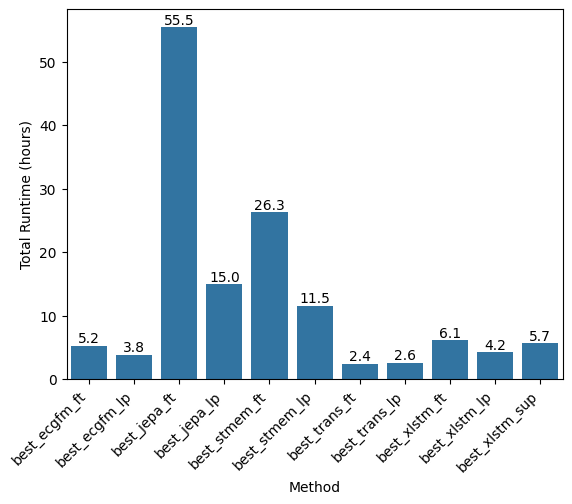

In [37]:
# for each row on all the dfs sum the runtime
# new dataframe with rows as group
runtime_data = {}
for df in [ptb_df, cpsc_df, mit_df, mit_r_peaks_df, exe_r_df, sleep_df, ppg_df, age_df, lab_df]:
    for index, row in df.iterrows():
        if index not in runtime_data.keys():
            print('adding index:', index)
            runtime_data[index] =  0
        # check if runtime is in df
        runtime_data[index] += row['_runtime']

runtime_df = pd.DataFrame.from_dict(runtime_data, orient='index') 
runtime_df = runtime_df.rename(columns={0: 'runtime'})
runtime_df['runtime'] = runtime_df['runtime'] / 3600

import seaborn as sns   

ax = sns.barplot(data=runtime_df, x=runtime_df.index, y='runtime')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
# add on top of the bar the number
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', rotation=0)
# set xtitle
ax.set_xlabel('Method')
ax.set_ylabel('Total Runtime (hours)')


# RANKING

In [64]:
categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Sleep<br>Apnea', 'PPG', 'Exercise', 'R-PEAK', 'Age', 'LAB test']
methods = ['ST-MEM', 'ECG-JEPA', 'ECG Founder', 'ours (transformer)', 'ours(xlstm)', 'supervised(xlstm)']

data = {
    'PTB-XL / AUC': [   ptb_df.loc['best_stmem_ft']['test_auroc'],
                        ptb_df.loc['best_jepa_ft']['test_auroc'], 
                        ptb_df.loc['best_ecgfm_ft']['test_auroc'], 
                        ptb_df.loc['best_trans_ft']['test_auroc'], 
                        ptb_df.loc['best_xlstm_ft']['test_auroc'],
                        ptb_df.loc['best_xlstm_sup']['test_auroc']],
    'CPSC2018 / AUC': [ cpsc_df.loc['best_stmem_ft']['test_auroc'],
                        cpsc_df.loc['best_jepa_ft']['test_auroc'], 
                        cpsc_df.loc['best_ecgfm_ft']['test_auroc'],
                        cpsc_df.loc['best_trans_ft']['test_auroc'],
                        cpsc_df.loc['best_xlstm_ft']['test_auroc'],
                        cpsc_df.loc['best_xlstm_sup']['test_auroc']],
    'MIT-BIH / F1': [   mit_df.loc['best_stmem_ft']['test_f1/mean'],
                        mit_df.loc['best_jepa_ft']['test_f1/mean'], 
                        mit_df.loc['best_ecgfm_ft']['test_f1/mean'],
                        mit_df.loc['best_trans_ft']['test_f1/mean'],
                        mit_df.loc['best_xlstm_ft']['test_f1/mean'],
                        mit_df.loc['best_xlstm_sup']['test_f1/mean']],
    'Sleep Apnea / AUC': [ sleep_df.loc['best_stmem_ft']['test_auc'],
                           sleep_df.loc['best_jepa_ft']['test_auc'], 
                           sleep_df.loc['best_ecgfm_ft']['test_auc'],
                           sleep_df.loc['best_trans_ft']['test_auc'],
                           sleep_df.loc['best_xlstm_ft']['test_auc'],
                           sleep_df.loc['best_xlstm_sup']['test_auc']],
    'PPG / AUC': [      ppg_df.loc['best_stmem_ft']['test_auroc'],
                        ppg_df.loc['best_jepa_ft']['test_auroc'], 
                        ppg_df.loc['best_ecgfm_ft']['test_auroc'],
                        ppg_df.loc['best_trans_ft']['test_auroc'],
                        ppg_df.loc['best_xlstm_ft']['test_auroc'],
                        ppg_df.loc['best_xlstm_sup']['test_auroc']],
    'Exercise / F1': [  exe_r_df.loc['best_stmem_ft']['test_f1_20'],
                        exe_r_df.loc['best_jepa_ft']['test_f1_20'], 
                        exe_r_df.loc['best_ecgfm_ft']['test_f1_20'],
                        exe_r_df.loc['best_trans_ft']['test_f1_20'],
                        exe_r_df.loc['best_xlstm_ft']['test_f1_20'],
                        exe_r_df.loc['best_xlstm_sup']['test_f1_20']],
    'R-Peaks / F1': [  mit_r_peaks_df.loc['best_stmem_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_jepa_ft']['test_f1_20'], 
                        mit_r_peaks_df.loc['best_ecgfm_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_trans_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_xlstm_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_xlstm_sup']['test_f1_20']],
    'Age / MAE': [      1 - age_df.loc['best_stmem_ft']['mean_rsmape'],
                        1 - age_df.loc['best_jepa_ft']['mean_rsmape'], 
                        1 - age_df.loc['best_ecgfm_ft']['mean_rsmape'],
                        1 - age_df.loc['best_trans_ft']['mean_rsmape'],
                        1 - age_df.loc['best_xlstm_ft']['mean_rsmape'],
                        1 - age_df.loc['best_xlstm_sup']['mean_rsmape']],
    'LAB test / AUC': [ lab_df.loc['best_stmem_ft']['test_auroc_avg'],
                        lab_df.loc['best_jepa_ft']['test_auroc_avg'],
                        lab_df.loc['best_ecgfm_ft']['test_auroc_avg'],
                        lab_df.loc['best_trans_ft']['test_auroc_avg'],
                        lab_df.loc['best_xlstm_ft']['test_auroc_avg'],
                        lab_df.loc['best_xlstm_sup']['test_auroc_avg']],
}# RANKING

df_raw = pd.DataFrame(data, index=methods)
df_raw.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC
ST-MEM,0.929916,0.958217,0.644478,0.727026,0.642692,0.985623,0.937266,0.930290,0.681346
ECG-JEPA,0.923336,0.965220,0.580663,0.587402,0.817191,0.857412,0.909293,0.925011,0.685941
ECG Founder,0.930447,0.969354,0.207143,0.580191,0.845594,0.081849,0.011331,0.922704,0.661043
ours (transformer),0.924652,0.965467,0.425415,0.604085,0.774292,0.631201,0.900353,0.914329,0.665705
ours(xlstm),0.927799,0.981308,0.677293,0.868879,0.890624,0.968012,0.920580,0.924435,0.691337
supervised(xlstm),0.890728,0.951107,0.402199,0.783209,0.876326,0.965772,0.889045,0.919468,0.639621


In [65]:
data_lp = {
    'PTB-XL / AUC': [   ptb_df.loc['best_stmem_lp']['test_auroc'],
                        ptb_df.loc['best_jepa_lp']['test_auroc'], 
                        ptb_df.loc['best_ecgfm_lp']['test_auroc'], 
                        ptb_df.loc['best_trans_lp']['test_auroc'], 
                        ptb_df.loc['best_xlstm_lp']['test_auroc']],
    'CPSC2018 / AUC': [ cpsc_df.loc['best_stmem_lp']['test_auroc'],
                        cpsc_df.loc['best_jepa_lp']['test_auroc'], 
                        cpsc_df.loc['best_ecgfm_lp']['test_auroc'],
                        cpsc_df.loc['best_trans_lp']['test_auroc'],
                        cpsc_df.loc['best_xlstm_lp']['test_auroc']],
    'MIT-BIH / F1': [   mit_df.loc['best_stmem_lp']['test_f1/mean'],
                        mit_df.loc['best_jepa_lp']['test_f1/mean'], 
                        mit_df.loc['best_ecgfm_lp']['test_f1/mean'],
                        mit_df.loc['best_trans_lp']['test_f1/mean'],
                        mit_df.loc['best_xlstm_lp']['test_f1/mean']],
    'Sleep Apnea / AUC': [ sleep_df.loc['best_stmem_lp']['test_auc'],
                           sleep_df.loc['best_jepa_lp']['test_auc'], 
                           sleep_df.loc['best_ecgfm_lp']['test_auc'],
                           sleep_df.loc['best_trans_lp']['test_auc'],
                           sleep_df.loc['best_xlstm_lp']['test_auc']],
    'PPG / AUC': [      ppg_df.loc['best_stmem_lp']['test_auroc'],
                        ppg_df.loc['best_jepa_lp']['test_auroc'], 
                        ppg_df.loc['best_ecgfm_lp']['test_auroc'],
                        ppg_df.loc['best_trans_lp']['test_auroc'],
                        ppg_df.loc['best_xlstm_lp']['test_auroc']],
    'Exercise / F1': [  exe_r_df.loc['best_stmem_lp']['test_f1_20'],
                        exe_r_df.loc['best_jepa_lp']['test_f1_20'], 
                        exe_r_df.loc['best_ecgfm_lp']['test_f1_20'],
                        exe_r_df.loc['best_trans_lp']['test_f1_20'],
                        exe_r_df.loc['best_xlstm_lp']['test_f1_20']],
    'R-Peaks / F1': [  mit_r_peaks_df.loc['best_stmem_lp']['test_f1_20'],
                        mit_r_peaks_df.loc['best_jepa_lp']['test_f1_20'], 
                        mit_r_peaks_df.loc['best_ecgfm_lp']['test_f1_20'],
                        mit_r_peaks_df.loc['best_trans_lp']['test_f1_20'],
                        mit_r_peaks_df.loc['best_xlstm_lp']['test_f1_20']],
    'Age / MAE': [      1 - age_df.loc['best_stmem_lp']['mean_rsmape'],
                        1 - age_df.loc['best_jepa_lp']['mean_rsmape'], 
                        1 - age_df.loc['best_ecgfm_lp']['mean_rsmape'],
                        1 - age_df.loc['best_trans_lp']['mean_rsmape'],
                        1 - age_df.loc['best_xlstm_lp']['mean_rsmape']],
    'LAB test / AUC': [ lab_df.loc['best_stmem_lp']['test_auroc_avg'],
                        lab_df.loc['best_jepa_lp']['test_auroc_avg'],
                        lab_df.loc['best_ecgfm_lp']['test_auroc_avg'],
                        lab_df.loc['best_trans_lp']['test_auroc_avg'],
                        lab_df.loc['best_xlstm_lp']['test_auroc_avg']],
}

df_lp_raw = pd.DataFrame(data_lp, index=methods[:-1])
df_lp_raw

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC
ST-MEM,0.867034,0.922097,0.424077,0.641669,0.653246,0.627345,0.564153,0.900687,0.657380
ECG-JEPA,0.902226,0.961038,0.496206,0.546437,0.476935,0.525400,0.444294,0.916946,0.666062
ECG Founder,0.917335,0.961727,0.205728,0.578864,0.640672,0.082386,0.010323,0.920547,0.652639
ours (transformer),0.913967,0.950829,0.395488,0.649323,0.655769,0.301576,0.476394,0.909381,0.671669
ours(xlstm),0.915361,0.967798,0.673956,0.797970,0.750782,0.891299,0.589917,0.920928,0.680801


In [66]:
# add color to each method for consistency
from plotly.colors import qualitative

colors = qualitative.Plotly[:len(df_raw)]
df_raw["color"] = colors
df_lp_raw["color"] = colors[:-1]

# add some alpha for better visibility
pastel_colors = [f"{color}C0" for color in colors]  #
df_raw["pastel_color"] = pastel_colors
df_lp_raw["pastel_color"] = pastel_colors[:-1]

df_raw.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,color,pastel_color
ST-MEM,0.929916,0.958217,0.644478,0.727026,0.642692,0.985623,0.937266,0.930290,0.681346,#636EFA,#636EFAC0
ECG-JEPA,0.923336,0.965220,0.580663,0.587402,0.817191,0.857412,0.909293,0.925011,0.685941,#EF553B,#EF553BC0
ECG Founder,0.930447,0.969354,0.207143,0.580191,0.845594,0.081849,0.011331,0.922704,0.661043,#00CC96,#00CC96C0
ours (transformer),0.924652,0.965467,0.425415,0.604085,0.774292,0.631201,0.900353,0.914329,0.665705,#AB63FA,#AB63FAC0
ours(xlstm),0.927799,0.981308,0.677293,0.868879,0.890624,0.968012,0.920580,0.924435,0.691337,#FFA15A,#FFA15AC0
supervised(xlstm),0.890728,0.951107,0.402199,0.783209,0.876326,0.965772,0.889045,0.919468,0.639621,#19D3F3,#19D3F3C0


In [68]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import plotly.io as pio

pio.templates.default = "plotly"  # Set default template to white background
import numpy as np

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

rows = 3
cols = 2

min_v = 0. # df_raw.min().min()
max_v = 1.# df_raw.max().max()
print(f"Min value: {min_v}, Max value: {max_v}")

num_methods = len(df_raw)
rows = 2
cols = 3
fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}],
           [{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=df_raw.index.tolist(),
    vertical_spacing=.1,  # Add vertical spacing between subplots
    horizontal_spacing=0.15  # Add horizontal spacing between subplots
)

gap = 1.0 / num_methods
padding = 0.06

for i, (idx, row) in enumerate(df_raw.iterrows()):

    current_row = (i // cols) + 1
    current_col = (i % cols) + 1
    #if i == len(df_z_scaled) -1:
    #    continue
    values = row.tolist()[:-2] + [row.tolist()[0]]  # close the loop
    print(values)
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=3, color=row['color']),
            hoverinfo='skip',
        ),
        row=current_row, col=current_col
    )

    if i < len(df_lp_raw):
        values = df_lp_raw.iloc[i].tolist()[:-2] + [df_lp_raw.iloc[i].tolist()[0]]  # close the loop
        values = [float(value) for value in values]
        print(values)
        fig.add_trace(
            go.Scatterpolar(
                r=values,
                theta=categories_closed,
                fill='toself',
                name=idx,
                line=dict(width=1, color=row['color']),
                hoverinfo='skip',
            ),
            row=current_row, 
            col=current_col
        )

    # Update polar layout for each subplot
    fig.update_layout({
        f'polar{i+1}': dict(
            angularaxis=dict(rotation=20),  # keep your rotation
            radialaxis=dict(
                visible=True, 
                range=[min_v, max_v], 
                showticklabels=False, 
                showline=False,
                showgrid=True,
            )
        )
    })


# Optional: adjust overall layout for better spacing
fig.update_layout(
    width=18,   # 88mm in pixels (88mm * 2.835 pixels/mm)
    # height=166.3,   # Maintain aspect ratio (2:3 -> height = width * 2/3)
    font=dict(family="Helvetica", size=12),  # Sans-serif font, 6pt (between 5-7pt range)
    showlegend=False,  # Hide legend since each subplot is labeled
    margin=dict(l=50, r=50, t=20, b=20)  # Tight margins for Nature format
)

fig.update_annotations(
    font=dict(size=14, family="Helvetica"),
    showarrow=False,
    #yshift=5,  # Adjust vertical position of titles
)


# save pdf
fig.write_image("radar_chart_methods.pdf")
# fig.show()

Min value: 0.0, Max value: 1.0
[0.9299159169197082, 0.9582167029380798, 0.644477641582489, 0.7270263195037842, 0.6426916718482971, 0.9856226921081543, 0.9372660756111145, 0.9302902852495512, 0.6813458323478698, 0.9299159169197082]
[0.8670340418815613, 0.9220970630645752, 0.4240765869617462, 0.6416686415672302, 0.653246283531189, 0.6273454189300537, 0.5641525387763977, 0.9006873870889346, 0.6573795795440673, 0.8670340418815613]
[0.9233355045318603, 0.9652199029922486, 0.5806627035140991, 0.5874020457267761, 0.8171910047531128, 0.8574116945266723, 0.9092930793762207, 0.9250108460585277, 0.6859411478042603, 0.9233355045318603]
[0.9022258758544922, 0.96103835105896, 0.4962062418460846, 0.5464372754096984, 0.4769346833229065, 0.5254004836082459, 0.44429364800453186, 0.9169460932413737, 0.6660620927810669, 0.9022258758544922]
[0.9304470181465149, 0.9693543076515198, 0.20714290738105773, 0.5801909327507019, 0.8455940246582031, 0.08184873461723327, 0.011331072822213174, 0.9227038477857907, 0.6

/tmp/ipykernel_2313336/838612998.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2313336/838612998.py:26: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2313336/838612998.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2313336/838612998.py:26: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



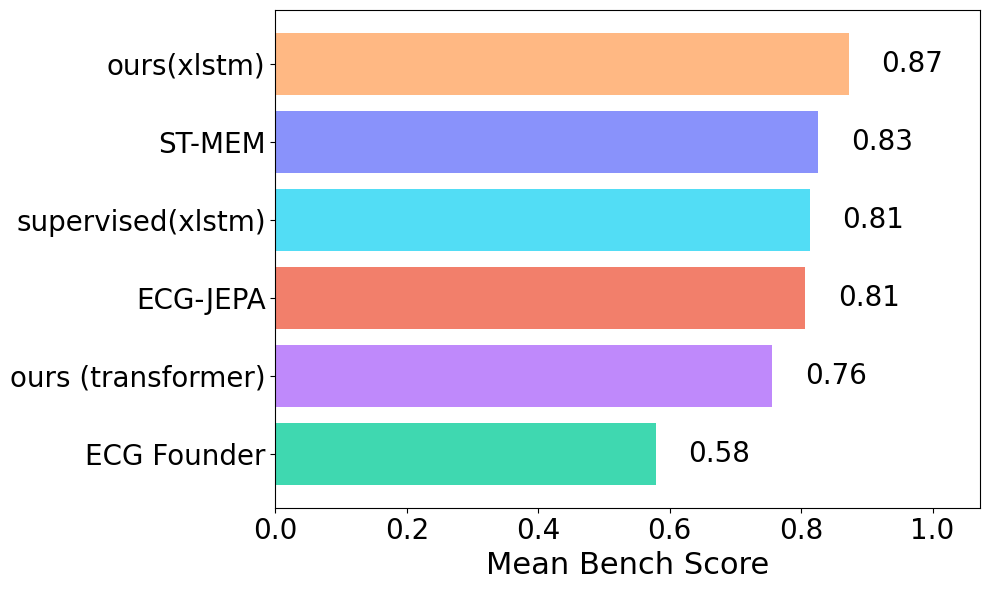

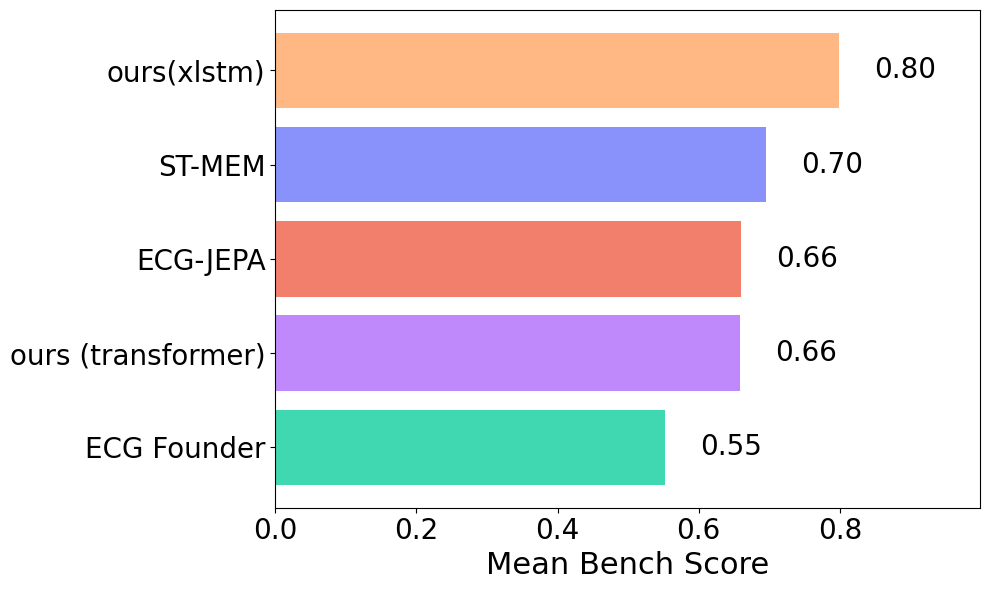

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.colors import qualitative
from matplotlib.ticker import MultipleLocator

def plot_bench_score(df, name='mean_score_methods.png'):
    # Prepare data
    df_ranked_sorted = df.copy()
    # drop colors columns
    df_ranked_sorted = df_ranked_sorted.drop(columns=["color", "pastel_color"])
    df_ranked_sorted["mean_score"] = df_ranked_sorted.mean(axis=1)
    # add the color column back for plotting
    df_ranked_sorted["pastel_color"] = df["pastel_color"]

    df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_score", ascending=False)

    # Generate color gradient
    norm = plt.Normalize(df_ranked_sorted["mean_score"].min(), df_ranked_sorted["mean_score"].max())
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_score"], color=df_ranked_sorted["pastel_color"])
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
    ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["mean_score"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

    # Format plot
    ax.set_xlabel('Mean Bench Score', fontsize=22)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["mean_score"].max() + 0.2])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig("mean_rank_methods.png", dpi=300)

plot_bench_score(df_raw, name='mean_score_methods.png')
plot_bench_score(df_lp_raw, name='mean_score_methods_lp.png')

In [ ]:
df = df_raw.drop(columns=["color", "pastel_color"]).copy()
# for every task get the rank
df["mean_rank"] = df.rank(ascending=False, method="min").mean(axis=1)

ST-MEM                2.666667
ECG-JEPA              3.555556
ECG Founder           4.333333
ours (transformer)    4.333333
ours(xlstm)           1.666667
supervised(xlstm)     4.444444
dtype: float64

/tmp/ipykernel_2313336/531969092.py:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2313336/531969092.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



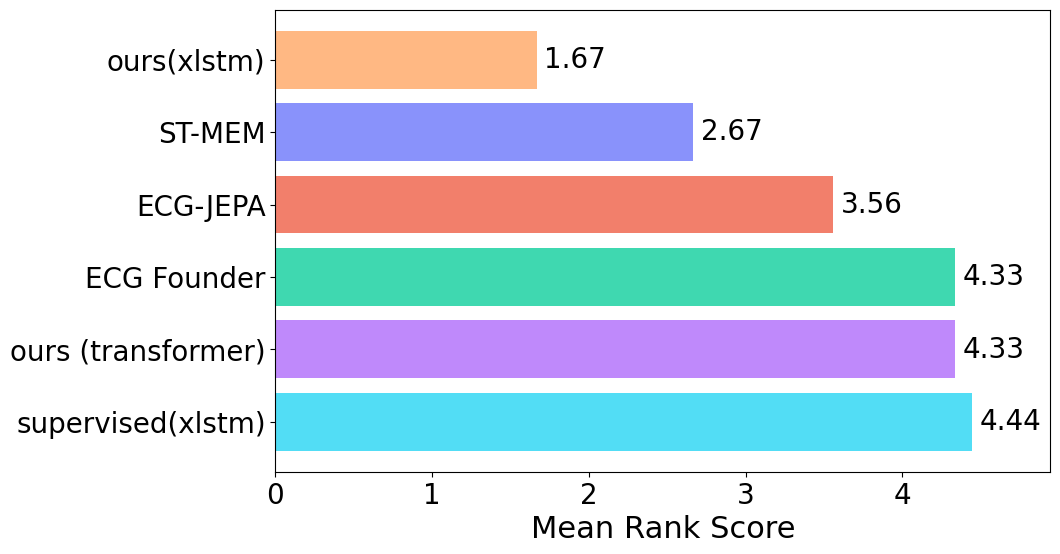

/tmp/ipykernel_2313336/531969092.py:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2313336/531969092.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



<Figure size 640x480 with 0 Axes>

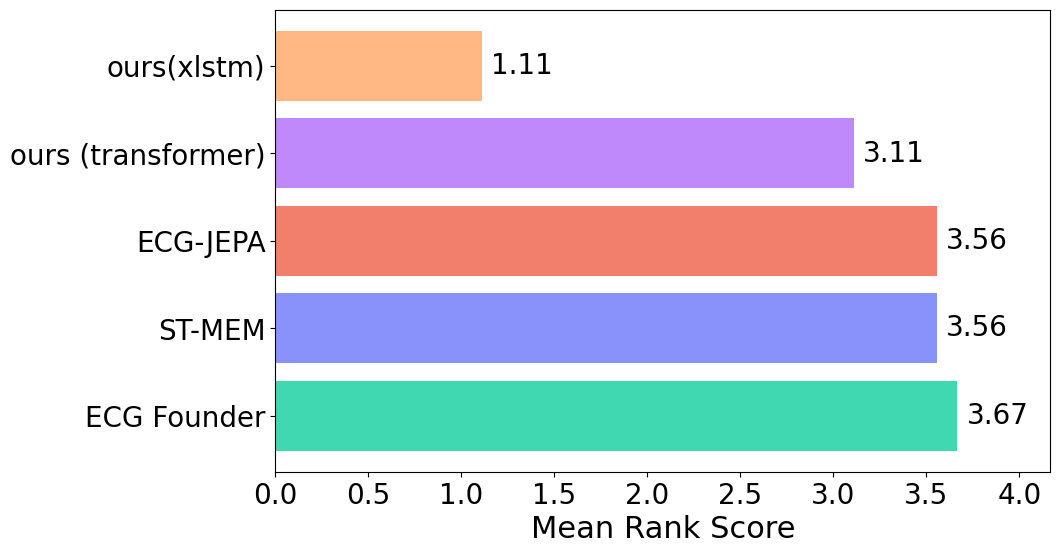

<Figure size 640x480 with 0 Axes>

In [85]:
import matplotlib.pyplot as plt

def plot_bench_rank(df, name='mean_rank_methods.png'):
    df_ranked_sorted = df.copy().drop(columns=["color", "pastel_color"])
    df_ranked_sorted["mean_rank"] = df_ranked_sorted.rank(ascending=False, method="min").mean(axis=1)
    df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_rank", ascending=True)

    df_ranked_sorted["pastel_color"] = df["pastel_color"]

    norm = plt.Normalize(df_ranked_sorted["mean_rank"].min(), df_ranked_sorted["mean_rank"].max())

    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color=df_ranked_sorted["pastel_color"])
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["mean_rank"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

    # Format plot
    ax.set_xlabel('Mean Rank Score', fontsize=22)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["mean_rank"].max() + 0.5])  # Adjust x-axis limit

    plt.show()
    plt.savefig(name, dpi=300)

plot_bench_rank(df_raw, "mean_rank_methods.png")
plot_bench_rank(df_lp_raw, "mean_rank_methods_lp.png")
